In [1]:
import NEXT
import NEXT.wforecast as wfc
import os
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import shapely as shp
from pynhd import WaterData, NLDI
from time import sleep
import warnings
import numpy as np
import datetime

# Prepare Environment

In [2]:
dirs = ["hist_data/", "hrrr_data/", "final_hist/", "gfs_raw/", "forecasts/", 'figures/', 'full_forecasts/']
for d in dirs:
    if not os.path.exists(d):
        os.mkdir(d)

# Identify Sites

By default, the forecast runs for 1,000 HUC-12 pour points sampled from across the contiguous US. You can modify this by changing the site selection below and removing the cached site file. The sampling procedure is to select 1,000 different HUC-8s, then sample one HUC-12 from each. (The actual default dataset contains 913 sites after misc errors.)

In [3]:
sitefile = "forecast_points.json"
run_sites = not os.path.exists(sitefile)

In [4]:
def try_and_sleep(f):
    sleep(5)
    try:
        return f()
    except:
        return None

# Wait between calls because otherwise it tends to overload the API
if run_sites:
    huc6 = WaterData("wbd06")
    huc12 = WaterData("wbd12")
    all_huc6 = huc6.bybox((-125, 25, -65, 50))
    huc12_samp = pd.concat([
        try_and_sleep(lambda: huc12.bygeom(x.geometry).sample(n=50)) # get extra samples because some will crash
        for x in all_huc6.itertuples()
    ]).sample(n=1200)
    pps = NLDI().getfeature_byid("huc12pp", huc12_samp["huc12"])
    geodata = (huc12_samp.loc[:, ["geometry", "huc12", "areasqkm"]].
        rename(columns={"huc12": "id", "areasqkm": "area"}).
        merge(
            pd.DataFrame({
                "id": pps["identifier"],
                "lat": pps.geometry.y,
                "lon": pps.geometry.x
            }),
            on="id"
        )).dropna().sample(1000)
    geodata.loc[:, "area"] = geodata["area"] * 1e6 # km2 -> m2
    geodata.to_file(sitefile)

else:
    geodata = gpd.read_file(sitefile)

<Axes: >

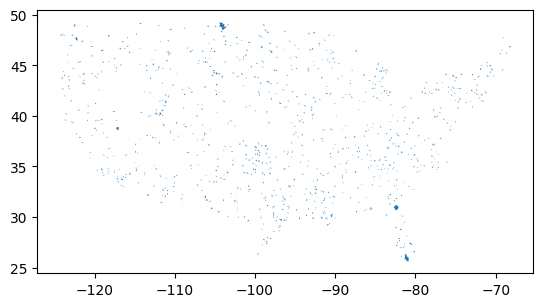

In [5]:
geodata.plot()

# Retrieve Historical Data

Humidity is retrieved from GridMet. Air temperature is from HRRR so that climatology will be more similar to GFS, for which NEXT doesn't have long-term archive retrieval (just recent forecast runs).

The below loops may crash periodically due to server errors. If so, just restart them, as they are set up to resume where they left off. GridMet retrieval takes several hours, and HRRR retrieval is currently exceptionally slow for no obvious reason, on the order of 1 hour per site. Due to that challenge, HRRR is only retrieved for one year for a sample of sites, which is used to fit a correction function.

In [6]:
runhist = len(os.listdir(dirs[2])) == 0

In [7]:
basepath = dirs[0] + "/"
if runhist:
    with warnings.catch_warnings(action="ignore"):
        for row in geodata.itertuples():
            fn = basepath + row.id + ".csv"
            if not os.path.exists(fn):
                # note: site type "huc12" doesn't actually exist. It will internally convert to coordinates.
                try:
                    NEXT.data.geom_full_data(row.id, "huc12", gpd.GeoSeries([row.geometry], crs=4326), row.lat, row.lon, row.area,
                                             "2015", "2025", "gridmet").to_csv(fn, index=False)
                except:
                    print(row.id)

The following block can be cancelled after several dozen sites have been retrieved.

In [8]:
if runhist:
    allids = [x.split('.')[0] for x in os.listdir(dirs[0])]  # don't run HRRR if we don't have other info
    basepath = dirs[1] + '/'
    with warnings.catch_warnings(action="ignore"):
        for row in geodata.itertuples():
            fn = basepath + row.id + ".csv"
            if (not os.path.exists(fn)) and (row.id in allids):
                NEXT.data.weather_hrrr(gpd.GeoSeries([row.geometry], crs=4326), "2025-01-01", "2025-12-31").to_csv(fn, index=False)

Compute corrections:

In [9]:
allids = [x.split('.')[0] for x in os.listdir(dirs[1])]
combined = pd.concat([
    pd.read_csv(dirs[0] + "/" + row.id + ".csv", parse_dates=["date"]).
        merge(pd.read_csv(dirs[1] + "/" + row.id + ".csv", parse_dates=["date"]),
              on="date",
              suffixes=["_gm", "_hrrr"])
    for row in geodata.itertuples()
    if row.id in allids
])

<Axes: xlabel='tmax_gm', ylabel='tmax_hrrr'>

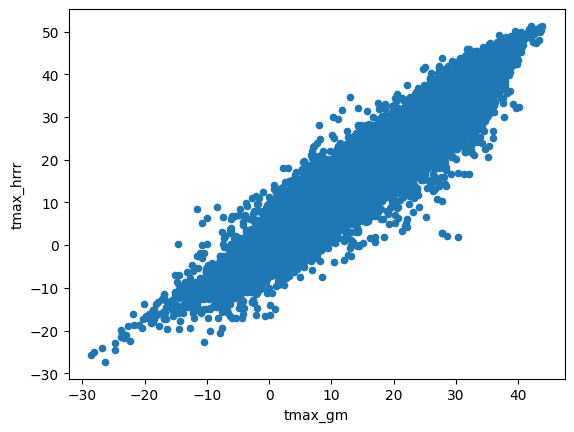

In [10]:
combined.plot.scatter(x="tmax_gm", y="tmax_hrrr")

In [11]:
combined["tmax_gm"].corr(combined["tmax_hrrr"])

np.float64(0.9543465835168514)

In [12]:
(combined.groupby("id")[["tmax_hrrr", "tmax_gm"]].corr().
    loc[(slice(None), "tmax_gm"), "tmax_hrrr"].describe())

count    78.000000
mean      0.945189
std       0.037704
min       0.762891
25%       0.935038
50%       0.956855
75%       0.967331
max       0.978917
Name: tmax_hrrr, dtype: float64

The relationship is imperfect, but we observe that sitewise correlation is nearly identical to global correlation, so a global correction can be applied.

In [13]:
fit = np.linalg.lstsq(
    np.array([np.ones(len(combined)), combined["tmax_gm"]]).T,
    combined["tmax_hrrr"])[0]

In [14]:
if runhist:
    for fn in os.listdir(dirs[0]):
        if fn.endswith('.csv'):
            data = pd.read_csv(dirs[0] + "/" + fn, parse_dates=["date"])
            data["tmax"] = data["tmax"] * fit[1] + fit[0]
            data.to_csv(dirs[2] + '/' + fn, index=False)

# Retrieve Forecast Data and Execute Forecasts

In [15]:
model = NEXT.NEXT.from_pickle('coefs_hrrr.pickle')

In [16]:
allids = [x.split('.')[0] for x in os.listdir(dirs[2])]
torun = geodata.loc[geodata['id'].isin(allids)]
earlier = (datetime.date.today() - datetime.timedelta(6)).strftime("%Y%m%d")
today = datetime.date.today().strftime("%Y%m%d")
with warnings.catch_warnings(action='ignore'):
    fcst_weath = (pd.concat([wfc.get_gfs_downloaded(torun, earlier, dirs[3]),
                             wfc.get_gfs_downloaded(torun, today, dirs[3])]).
        groupby(["id", "date"], as_index=False)["tmax"].last().sort_values("date"))
    for row in torun.itertuples():
        infn = dirs[2] + row.id + '.csv'
        outfn = dirs[4] + row.id + '_' + today + '.csv'
        if not os.path.exists(outfn):
            try:
                model.make_newt(pd.read_csv(infn, parse_dates=['date']), reset=True)
                model.run(fcst_weath.loc[fcst_weath['id'] == row.id]).to_csv(outfn, index=False)
            except KeyboardInterrupt:
                break
            except:
                print(row.id)

080901000101


# Analyze The Forecast

In [17]:
today = datetime.date.today().strftime("%Y%m%d")
forecast = pd.concat([
    pd.read_csv(dirs[4] + fn, parse_dates=['date']).
        assign(id = fn.split('_')[0])
    for fn in os.listdir(dirs[4])
    if today in fn and fn.endswith('.csv')
])
# Limit to weekly forecast
forecast = forecast.loc[(forecast['date'] >= np.datetime64('today')) &
    (forecast['date'] < np.datetime64('today') + 7)]
forecast = forecast.merge(geodata, on='id').dropna()
forecast.drop(columns=['day', 'period', 'geometry']).to_csv(dirs[6] + today + '.csv', index=False)
forecast

,id,date,tmax,day,period,prediction,seasonal,anomaly,area,lat,lon,geometry
0,030101070701,2026-04-09,18.482259,99,99,14.695371,16.789238,-2.093867,35360000.0,36.130745,-77.131924,"MULTIPOLYGON (((-77.16046 36.22118, -77.15999 ..."
1,030101070701,2026-04-10,23.035169,100,100,15.415939,16.927332,-1.511393,35360000.0,36.130745,-77.131924,"MULTIPOLYGON (((-77.16046 36.22118, -77.15999 ..."
2,030101070701,2026-04-11,24.708333,101,101,15.910602,17.065124,-1.154522,35360000.0,36.130745,-77.131924,"MULTIPOLYGON (((-77.16046 36.22118, -77.15999 ..."
3,030101070701,2026-04-12,22.973520,102,102,16.424426,17.202578,-0.778152,35360000.0,36.130745,-77.131924,"MULTIPOLYGON (((-77.16046 36.22118, -77.15999 ..."
4,030101070701,2026-04-13,25.681637,103,103,16.371084,17.339659,-0.968574,35360000.0,36.130745,-77.131924,"MULTIPOLYGON (((-77.16046 36.22118, -77.15999 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...
6449,150400060402,2026-04-11,26.945108,101,101,14.661120,16.679355,-2.018235,71920000.0,32.218333,-109.114909,"MULTIPOLYGON (((-109.02855 32.2684, -109.02875..."
6450,150400060402,2026-04-12,24.990107,102,102,14.579653,16.715101,-2.135447,71920000.0,32.218333,-109.114909,"MULTIPOLYGON (((-109.02855 32.2684, -109.02875..."
6451,150400060402,2026-04-13,23.067879,103,103,14.450709,16.751029,-2.300320,71920000.0,32.218333,-109.114909,"MULTIPOLYGON (((-109.02855 32.2684, -109.02875..."
6452,150400060402,2026-04-14,20.455279,104,104,14.072970,16.787130,-2.714160,71920000.0,32.218333,-109.114909,"MULTIPOLYGON (((-109.02855 32.2684, -109.02875..."


In [18]:
# Export to mappable GeoJSON. Modify this code to set custom color scales. These column
# labels work with CalTopo.
fcjs = forecast.groupby(['lat', 'lon', 'id'])['prediction'].agg(['mean', 'min', 'max'])
fcjs = gpd.GeoDataFrame(fcjs,
                        geometry = [
                            shp.Point(x.lon, x.lat)
                            for x in fcjs.reset_index().itertuples()
                        ],
                        crs=4326)
fcjs['marker-size'] = 2
fcjs['title'] = fcjs.index.get_level_values('id')
fcjs['marker-color'] = "0000FF"
fcjs.loc[fcjs['mean'] > 10, 'marker-color'] = "008080"
fcjs.loc[fcjs['mean'] > 13, 'marker-color'] = "00FF00"
fcjs.loc[fcjs['mean'] > 16, 'marker-color'] = "808000"
fcjs.loc[fcjs['mean'] > 20, 'marker-color'] = "FF0000"
fcjs.to_file(dirs[6] + today + '_map.json')

## Forecast Description

Warning: this is an experimental stream water temperature forecast for the upcoming week. Results are not guaranteed in any capacity. Typical errors are approximately 2.5 C (4 F); any given prediction may have considerably higher errors. For example, in the southern Rocky Mountains during the first forecast run (April 2026), the model, while it did predict high temperature anomalies, was unable to fully account for the unseasonal loss of snowpack and therefore underpredicted temperatures by several degrees.

These data and related items of information have not been formally disseminated by NOAA, and do not represent any agency determination, view, or policy. This research is funded by the NOAA Cooperative Institute for Research to Operations in Hydrology.

The code used to generate these forecasts is available on GitHub at https://github.com/mines-ciroh/natl-temp-forecast (requires support for ecCodes, for which Linux is recommended). Additionally, required preliminary data for the 913 default forecast sites are available on the GitHub Releases page, so the only data retrieval required is the GFS forecast download. Actual weekly forecasts are made available on CUAHSI HydroShare at http://www.hydroshare.org/resource/b8852529788a437a8d697e9b0435b99a.

The US states shapefile was retrieved from https://www.census.gov/geographies/mapping-files/time-series/geo/carto-boundary-file.html, and the large rivers shapefile from https://www.weather.gov/gis/Rivers. Both were converted to GeoJSON.

In [19]:
forecast[['seasonal', 'anomaly', 'prediction']].describe()

,seasonal,anomaly,prediction
count,6454.000000,6454.000000,6454.000000
mean,11.986590,-0.572947,11.413643
std,6.717506,1.455125,6.472956
min,-7.570524,-8.022744,0.000000
25%,6.848815,-1.306349,6.336883
50%,11.336830,-0.594499,10.828958
75%,17.674270,0.171092,16.930688
max,31.989567,8.773664,32.259584


In [ ]:
states = gpd.read_file("states.json")
states = states.loc[~states["STUSPS"].isin(["AK", "HI", "PR"])]  # CONUS
rivers = gpd.read_file("rivers.json")

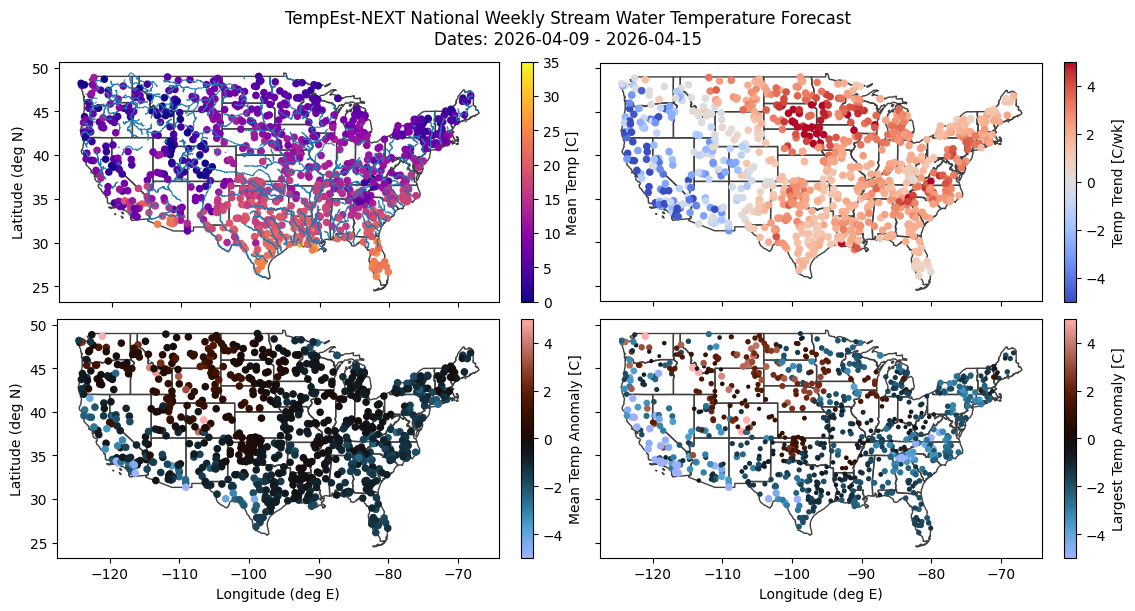

In [65]:
def signed_max_abs(series):
    # Find the largest absolute value, preserving sign
    mx = series.max()
    mn = series.min()
    if abs(mx) >= abs(mn):
        return mx
    return mn
def scale_size(series, mn=1, mx=5, ceiling=5):
    series = series.abs()
    series.loc[series > ceiling] = ceiling
    return mn + (series - series.min()) * (mx - mn) / (series.max() - series.min())

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(12, 6), layout='compressed')
for axr in axes:
    for ax in axr:
        states.plot(facecolor="none", edgecolor="#404040", ax=ax)
(forecast.groupby('id')[['lat', 'lon', 'prediction']].mean().
    rename(columns={'prediction': 'Mean Temp [C]'}).
    plot.scatter(
    x='lon', y='lat', c='Mean Temp [C]',
        cmap='plasma', vmin=0, vmax=35, ax=axes[0, 0],
    ylabel='Latitude (deg N)', xlabel='Longitude (deg E)'))
rivers.loc[rivers["STRAHLER"] > 3].plot(ax=axes[0, 0], linewidth=0.8)
(forecast.groupby('id').agg({'lat': 'mean', 'lon': 'mean', 'anomaly': 'mean'}).
    rename(columns={'anomaly': 'Mean Temp Anomaly [C]'}).
    plot.scatter(
    x='lon', y='lat', c='Mean Temp Anomaly [C]',
        cmap='berlin', vmin=-5, vmax=5, ax=axes[1, 0],
    ylabel='Latitude (deg N)', xlabel='Longitude (deg E)'))
(forecast.groupby('id').agg({'lat': 'mean', 'lon': 'mean', 'anomaly': signed_max_abs}).
    assign(anomsize=lambda x: scale_size(x['anomaly'], mn=3, mx=20)).
    rename(columns={'anomaly': 'Largest Temp Anomaly [C]'}).
    plot.scatter(
    x='lon', y='lat', c='Largest Temp Anomaly [C]', s='anomsize',
        cmap='berlin', vmin=-5, vmax=5, ax=axes[1, 1],
    ylabel='Latitude (deg N)', xlabel='Longitude (deg E)'))
# Compute weekly *trend*
start = forecast.loc[forecast['date'] == forecast['date'].min()].set_index('id')
end = forecast.loc[forecast['date'] == forecast['date'].max()].set_index('id')
start.loc[:, 'Temp Trend [C/wk]'] = end['prediction'] - start['prediction']
start.plot.scatter(x='lon', y='lat', c='Temp Trend [C/wk]',
        cmap='coolwarm', vmin=-5, vmax=5, ax=axes[0, 1],
    ylabel='Latitude (deg N)', xlabel='Longitude (deg E)')
fig.suptitle(f'''TempEst-NEXT National Weekly Stream Water Temperature Forecast
Dates: {forecast['date'].min().date()} - {forecast['date'].max().date()}''')
fig.savefig(dirs[5] + f'ForecastPlot_{today}.png', dpi=300)